---
short_title: Visualisierung
numbering:
    heading_1: true
    heading_2: true
    title: true
---

# Daten visualisieren

```{caution} Work In Progress
Diese Inhalte sind noch in Bearbeitung.
```

Zahlen allein sind schwer zu erfassen. Diagramme machen Muster sichtbar. Wir
nutzen die {term}`Bibliothek` **{term}`Matplotlib`**, die eng mit {term}`Pandas` zusammenarbeitet.

Alle Diagramme erhalten **deutsche Beschriftungen** (Achsen und Titel) – so sind
sie auch in deutschsprachigen Berichten direkt einsetzbar. Die fertigen
Abbildungen speichern wir unter `assets/090/` als PNG-Datei.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 5)

```{note}
**Hinweis zur Browser-Version:** Der Python-Kernel von JupyterLite (über den
Start-Knopf der Seite) läuft im Browser und hat ein anderes Environment als
Ihre lokale Installation: Die Beispieldatei
`assets/data/bibliothek_unsauber.xlsx` liegt dort nicht im Projekt, und die
Excel-Engine `openpyxl` fehlt. Die folgende Zelle lädt beides **nur im
Browser** von der Kurs-Website nach (erkannt an
`sys.platform == "emscripten"`). Lokal in JupyterLab tut sie nichts.
```

In [ ]:
import sys

# Pyodide (JupyterLite) meldet sich mit der Plattform "emscripten";
# lokal (JupyterLab, Build) ist sie z. B. "darwin" oder "linux".
if sys.platform == "emscripten":
    from pathlib import Path

    from js import location

    # 1) Excel-Engine openpyxl fehlt in JupyterLite. Die Wheels liegen auf
    #    der Kurs-Website (Ordner assets/pypi) und werden direkt installiert.
    import micropip

    _wheels = (
        "et_xmlfile-2.0.0-py3-none-any.whl",
        "openpyxl-3.1.5-py2.py3-none-any.whl",
    )
    _fehler = None
    for _basis in (f"{location.origin}/pypi", "pypi"):
        try:
            await micropip.install(
                [f"{_basis}/{_w}" for _w in _wheels], keep_going=True
            )
            _fehler = None
            break
        except Exception as _e:  # noqa: BLE001
            _fehler = _e
    if _fehler is not None:
        raise RuntimeError(f"openpyxl konnte nicht installiert werden: {_fehler}")

    # 2) Beispieldatei von der Kurs-Website ins virtuelle Dateisystem laden,
    #    sodass relative Pfade wie "../assets/data/..." funktionieren
    def stelle_daten_bereit(pfad):
        """Lädt eine Beispieldatei von der Kurs-Website ins virtuelle Dateisystem."""
        ziel = Path(pfad)
        if ziel.exists():
            return ziel

        from js import XMLHttpRequest

        for url in (f"{location.origin}/{ziel.name}", ziel.name):
            anfrage = XMLHttpRequest.new()
            # synchron möglich, weil der Kernel in einem Web Worker läuft
            anfrage.open("GET", url, False)
            try:
                anfrage.responseType = "arraybuffer"
                anfrage.send()
            except Exception:
                continue  # nächste Kandidaten-URL versuchen
            if anfrage.status == 200:
                inhalt = anfrage.response.to_py()
                if not isinstance(inhalt, str):  # ArrayBuffer -> Bytes
                    ziel.parent.mkdir(parents=True, exist_ok=True)
                    ziel.write_bytes(bytes(inhalt))
                    return ziel
        raise FileNotFoundError(
            f"{pfad} weder lokal noch auf der Kurs-Website gefunden."
        )

    stelle_daten_bereit("../assets/data/bibliothek_unsauber.xlsx")

    # 3) Ausgabeverzeichnis für die Abbildungen sicherstellen
    Path("../assets/090").mkdir(parents=True, exist_ok=True)

In [2]:
STANDORT_MAPPING = {
    "ZB": "Zentralbibliothek",
    "zentralbibliothek": "Zentralbibliothek",
    "Nord": "Zweigstelle Nord",
    "Zweigstelle Nord": "Zweigstelle Nord",
    "Süd": "Zweigstelle Süd",
    "Zweigstelle Sued": "Zweigstelle Süd",
    "Zweigstelle Süd": "Zweigstelle Süd",
    "West": "Campus West",
    "campus west": "Campus West",
    "Campus West": "Campus West",
    "mag": "Magazin",
    "MAG": "Magazin",
    "Magazin": "Magazin",
    "Zentralbibliothek": "Zentralbibliothek",
}

In [3]:
MEDIUM_MAPPING = {
    "buch": "Buch",
    "Buch": "Buch",
    "eBook": "E-Book",
    "E-Book": "E-Book",
    "zeitschrift": "Zeitschrift",
    "Zeitschr.": "Zeitschrift",
    "Zeitschrift": "Zeitschrift",
    "dvd": "DVD",
    "DVD": "DVD",
    "hoerbuch": "Hörbuch",
    "Hörbuch": "Hörbuch",
}

In [4]:
def parse_deutsche_zahl(serie):
    """Wandelt Text mit deutschem Tausenderpunkt in Zahlen um."""
    text = serie.astype("string").str.strip()
    hat_tausenderpunkt = text.str.match(r"^-?\d{1,3}(\.\d{3})+$", na=False)
    text = text.where(~hat_tausenderpunkt, text.str.replace(".", "", regex=False))
    return pd.to_numeric(text, errors="coerce")

In [5]:
def bereinige(pfad):
    """Liest die unsaubere Excel-Datei ein und gibt saubere Daten zurueck."""
    df = pd.read_excel(pfad, sheet_name="Ausleihen")
    df = df.drop_duplicates().reset_index(drop=True)

    df["Standort"] = df["Standort"].str.strip().map(STANDORT_MAPPING)
    df["Medium"] = df["Medium"].str.strip().map(MEDIUM_MAPPING)

    df["Erscheinungsjahr"] = pd.to_numeric(
        df["Erscheinungsjahr"].astype("string").str.strip(), errors="coerce"
    )
    df["Ausleihzahlen"] = parse_deutsche_zahl(df["Ausleihzahlen"])
    df["Zugangsdatum"] = pd.to_datetime(
        df["Zugangsdatum"], format="mixed", dayfirst=True, errors="coerce"
    )

    df = df.rename(columns={
        "Titel": "titel",
        "Autor*in": "autor",
        "Erscheinungsjahr": "jahr",
        "Ausleihzahlen": "ausleihen",
        "Standort": "standort",
        "Medium": "medium",
        "Zugangsdatum": "zugang",
    })
    return df.dropna(subset=["titel", "autor"]).reset_index(drop=True)

In [6]:
bibliothek = bereinige("../assets/data/bibliothek_unsauber.xlsx")
bibliothek.head()

,titel,autor,jahr,ausleihen,standort,medium,zugang
0,Metadaten in der Praxis,"Behrens, Carl",2007,8,Magazin,DVD,2007-03-23
1,Grundlagen der Katalogisierung,"Dittrich, Erik",<NA>,186,Campus West,Zeitschrift,2013-04-22
2,Digitalisierung im Archiv,"Engel, Friederike",1993,21,Magazin,E-Book,1993-06-13
3,Open Access verstehen,"Fischer, Gerd",2024,<NA>,Zweigstelle Süd,E-Book,2024-07-19
4,Bibliotheken im digitalen Wandel,"Hoffmann, Ingo",2006,395,Campus West,E-Book,2006-03-17


## Balkendiagramm: Ausleihen je Standort

Ein Balkendiagramm vergleicht Kategorien. Wir summieren die Ausleihzahlen je
Standort und sortieren absteigend.

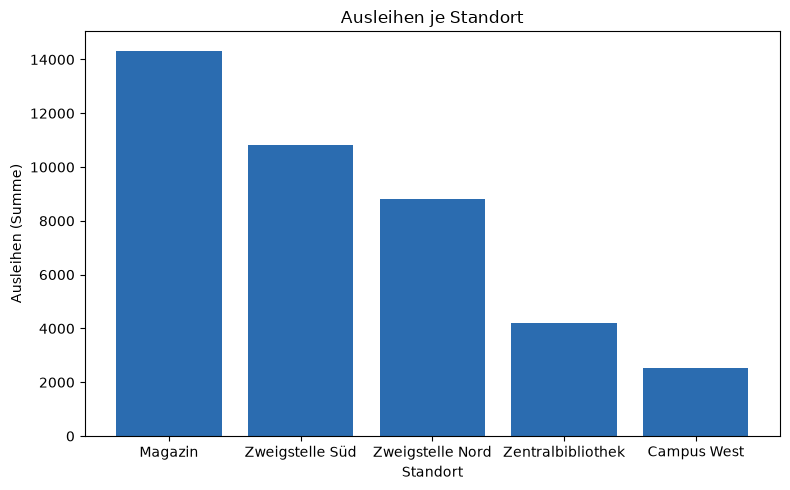

In [7]:
ausleihen_standort = (
    bibliothek.groupby("standort")["ausleihen"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots()
ax.bar(ausleihen_standort.index, ausleihen_standort.values, color="#2b6cb0")
ax.set_title("Ausleihen je Standort")
ax.set_xlabel("Standort")
ax.set_ylabel("Ausleihen (Summe)")
fig.tight_layout()
fig.savefig("../assets/090/ausleihen_je_standort.png", dpi=150)
plt.show()

## Liniendiagramm: Ausleihen nach Erscheinungsjahr

Eine Linie eignet sich für zeitliche Verläufe. Wir summieren die Ausleihen je
Erscheinungsjahr.

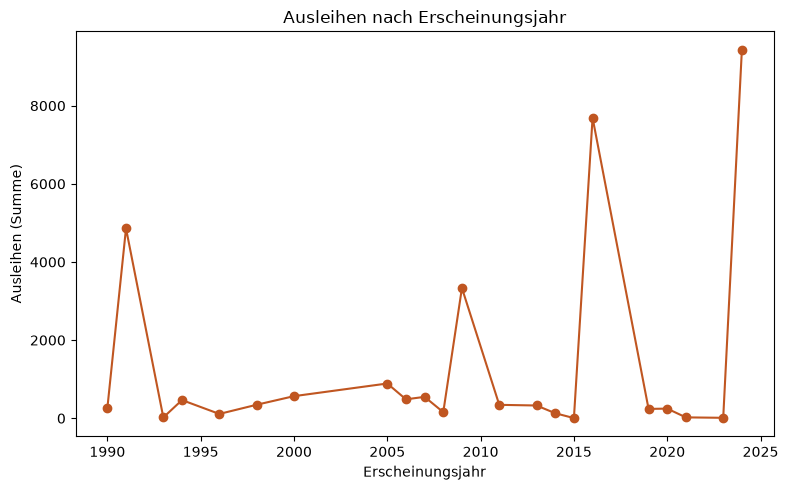

In [8]:
ausleihen_jahr = bibliothek.groupby("jahr")["ausleihen"].sum().sort_index()

fig, ax = plt.subplots()
ax.plot(ausleihen_jahr.index, ausleihen_jahr.values, marker="o", color="#c05621")
ax.set_title("Ausleihen nach Erscheinungsjahr")
ax.set_xlabel("Erscheinungsjahr")
ax.set_ylabel("Ausleihen (Summe)")
fig.tight_layout()
fig.savefig("../assets/090/ausleihen_nach_jahr.png", dpi=150)
plt.show()

## Histogramm: Verteilung der Ausleihzahlen

Ein Histogramm zeigt, wie sich die Werte einer Variablen verteilen. Die `bins`
legen die Anzahl der Klassen fest.

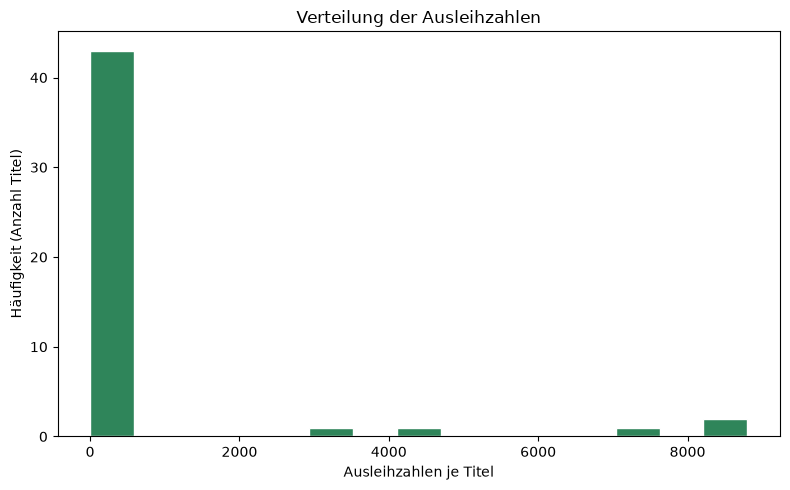

In [9]:
werte = bibliothek["ausleihen"].dropna()

fig, ax = plt.subplots()
ax.hist(werte, bins=15, color="#2f855a", edgecolor="white")
ax.set_title("Verteilung der Ausleihzahlen")
ax.set_xlabel("Ausleihzahlen je Titel")
ax.set_ylabel("Häufigkeit (Anzahl Titel)")
fig.tight_layout()
fig.savefig("../assets/090/verteilung_ausleihzahlen.png", dpi=150)
plt.show()

## Layout und Speichern

* `fig, ax = plt.subplots()` legt eine Zeichenfläche (`fig`) und eine
  Achsenfläche (`ax`) an. Das ist übersichtlicher als die Kurzschreibweise.
* `fig.tight_layout()` verhindert, dass Beschriftungen abgeschnitten werden.
* `fig.savefig(pfad, dpi=150)` schreibt das Diagramm als PNG-Datei; höherer
  `dpi` bedeutet schärfere Bilder.
* Im Notebook wird das Diagramm direkt unter der Zelle angezeigt und ist
  damit Teil Ihrer Abgabe. Eine separate Bilddatei müssen Sie nicht in ein
  anderes Dokument einbinden.

## Übung

````{exercise}
:label: visualisierung-uebung

1. Erstellen Sie ein Balkendiagramm der Ausleihen je Medium (Titel:
   „Ausleihen je Medium“).
2. Erstellen Sie ein Histogramm der Erscheinungsjahre und interpretieren Sie
   die Verteilung.
3. Speichern Sie mindestens eine Abbildung unter `assets/090/` als
   PNG-Datei.

````

## Selbsttest

Prüfen Sie zum Abschluss des Moduls Ihr Verständnis. Wählen Sie jeweils die passende Antwort aus.

In [ ]:
from jupyterquiz import display_quiz
c = { '--jq-multiple-choice-bg': '#202080',
      '--jq-mc-button-bg': '#fafafa',
      '--jq-mc-button-border': '#e0e0e0e0',
      '--jq-mc-button-inset-shadow': '#555555',
      '--jq-many-choice-bg': '#202080',
      '--jq-numeric-bg': '#202080',
      '--jq-numeric-input-bg': '#c0c0c0',
      '--jq-numeric-input-label': '#101010',
      '--jq-numeric-input-shadow': '#999999',
      '--jq-string-bg': '#202080',
      '--jq-incorrect-color': '#c80202',
      '--jq-correct-color': '#009113',
      '--jq-text-color': '#fafafa',
      '--jq-link-color': '#9abafa' }


In [ ]:
q = [{
        "question": "Mit welcher Funktion liest man eine Excel-Datei in pandas ein?",
        "type": "multiple_choice",
        "answers": [
            { "code": "pd.read_excel(...)", "correct": True },
            { "code": "pd.read_csv(...)", "correct": False },
            { "code": "pd.open_excel(...)", "correct": False },
            { "code": "pd.load_excel(...)", "correct": False }
        ]
    },
    {
        "question": "Welche Angabe liefert die Anzahl der Zeilen und Spalten?",
        "type": "multiple_choice",
        "answers": [
            { "code": "df.shape", "correct": True },
            { "code": "df.size", "correct": False },
            { "code": "df.info()", "correct": False },
            { "code": "df.columns", "correct": False }
        ]
    },
    {
        "question": "Welche Methode entfernt doppelte Zeilen?",
        "type": "multiple_choice",
        "answers": [
            { "code": "df.drop_duplicates()", "correct": True },
            { "code": "df.dropna()", "correct": False },
            { "code": "df.unique()", "correct": False },
            { "code": "df.duplicated()", "correct": False }
        ]
    },
    {
        "question": "Mit welcher Methode fasst man Zeilen mit gleichem Wert zusammen?",
        "type": "multiple_choice",
        "answers": [
            { "code": "groupby()", "correct": True },
            { "code": "merge()", "correct": False },
            { "code": "sort_values()", "correct": False },
            { "code": "value_counts()", "correct": False }
        ]
    },
    {
        "question": "Wie viele Zeilen bleiben in der Musterlösung nach der Bereinigung übrig?",
        "type": "string",
        "answers": [
            { "answer": "53", "correct": True,
              "feedback": "Richtig. Aus 65 Rohzeilen werden nach Duplikatentfernung und Bereinigung 53 Zeilen." }
        ]
    }]
display_quiz(q, colors=c)
